__План занятия__
1. Постановка задачи и обзор методов
2. Виды распределений
3. Генерация без референса (по метаданным)
    - random
    - sklearn.datasets
4. Генерация с референсом (по данным)
5. Faker
6. SDV
7. Вайб-генерация
8. Оценка качества генерации
9. Непараметрические методы генерации

# 1. Введение
---

__Синтетика__ = сгенерированные данные, сохраняющие все свойства реальных и внешне неотличимые от них

Пусть реальные данные описываются своим распределением $x \propto P_X$, тогда задача - построить такое распрделение $P_{theta} \rightarrow P_X$, которое было бы приближенную к реальному распределению

Типовые сценарии, когда могут понадобиться синтетические данные
- ограничения приватности (Privacy Issues)
    - данные содержат PII данные, их доступность ограничивается законом  
    - данные содержат чувствительную информацию, которую владелец не готов раскрывать (бизнес показатели, планы итд)
    - данные для соревнований или учебных проектов <br>требуют высокой анонимизации, изначально расчитаны на широкую аудиторию
    - кейс: доступ пока согласуется, а работать с данными уже нужно
- мало данных
    - собрали недостаточно
    - нужно больше данных для Proof-of-concept решения
    - исследуется закон масштабирования - нужен условно "неограниченный" набор данных<br>пример задачи: как изменятся показатели ML модели (performance, latency, etc), если мы кратно увеличиваем размер входных данных x10, x100, x1000
    - симуляции процессов
        - роботы / навигация<br>для обучения сложных агентов нужно много сгенерированных данных среды выскокой достоверност
        - stress-testing<br>как поведет себя сервис под нагрузкой
- данные несбалансированные<br>данные разделены на классы и один из классов преобладает на другими

В сфере больших моделей:<br>
на 2025 выбраны почти все доступные данные, качественных данных (задания, иснтрукции) ещё меньше<br>прогноз - к 2030 году сети будут обучаться преимущесвтенно на синтетических данных

Типы данных для синтезирования:
- скалярные (числовые, категориальные)<br>
- строки таблиц (tabular data)<br>наборы перменных разных типов
- временные ряды<br>например, для моделирования финансовых процессов
- текст, картинки<br>
- базы данных<br>наборы таблиц со связями
- траектории движения
- и т.п.

Этот набор условно неограниен, ведь синтетические данные позволяют сильно удешевить и масштабировать процесс обучения моделей. Уже сейчас языковые модели генерируют промпты для обучения других моделей

В задачах генерации часто возникают специальные данные, имеющие регулярный формат. Это усложняет процесс генерации<br>
Примеры:
- ФИО
- адреса
- телефоны
- номер карты
- почтовый индекс
- дата/время
- валюта
- названия компаний
- и т.д.

Другие сложности - это наличие корреляций и бизнес-правил, ограничивающих множество допустимых значний

Требования к качеству синтетики опаределяются задачей! Цели варьируются от "проверить техническую работоспособность" до "использовать в качестве бенчмарка в исследованиях"

Что касается инструментов для генерации, тут как всегда пирамида - если контроль в приоритете, исполь низкоуровневые инструменты, если быстрота - высокоуровневые

Таксономия инструментов:
- __код__<br>pros: полный контроль, но много писать
    - Python/R скрипты, генерирующие случайные данные
        - random
        - numpy.random
    - SQL-скрипты для генерации тестовых таблиц (например, случайные даты/числа для имитации транзакций)
    - Симуляции: написание собственного генератора событий (например, логов пользователей сайта с определённым распределением действий)
    - нейросетевые генераторы на базе PyTorch / TensorFlow (с помощью GAN, Diffusion, VAE)
- __библиотеки для генерации__
    - Faker (имена, адреса, транзакции)
    - SDV (Synthetic Data Vault) – мощный набор Python-библиотек от MIT для табличных, последовательных, иерархических данных
    - YData Synthetic – библиотека на основе GAN/VAE для табличных данных
- __модули в ML-библиотеках__
    - Pandas.datasets - генерирует тестовые наборы
    - Numpy / Scipy.stats – генерация случайных чисел из распределений (нормальное, пуассоновское и т.д.)
- __внешние сервисы__
    - Mostly AI – лидер рынка synthetic data, акцент на приватности и регуляторике
    - Gretel.ai – генерация текстовых, табличных и последовательных данных, API-first
    - Hazy – сервис для финансового сектора, синтетические данные для тестов
    - Tonic.ai – интеграция с базами данных, генерация синтетических тестовых данных
    - Synthesized.io – автоматическая анонимизация и генерация
- __LLMs__<br>пишется промт с описанием требований по структуре данных. возможно ипользовать знания модели по генерируемым объектам (смоделируй стоимость квартир в Москве)
    - Copilot
    - Claude




### Литература
- [[Bauer et al (2024)]](https://arxiv.org/abs/2401.02524)<br>обзор методов генерации (400+ штук)
- ыввыа

__Почему такое разнообразие:__ постановка достатосчно общая. В широком смысле ML изучает структуру данных, а структура необзодимо для решения любых задач, будь то генеративный  подход. Поэтому почти всё, что было предложено за последние 50+ лет изучения, может быть предложено как способ генерации новых данных

## Генераторы в Python
Можно использовать любой из 3х доступных модулей:
- __random__<br>самый базовый, подходит для ad-hoc генерации<br><br>
- __numpy.random__<br>[docs](https://numpy.org/doc/2.3/reference/random/index.html)<br>имеет возможность генерировать сразу вектор значений благодарая аргументу 'size'<br>больше распределений и более продуманные названия методов<br>```df['new_feature'] = numpy.random.lognorm(pos=0, scale=1, size=1000)```<br><br>
- __scipy.stats__<br>[docs](https://docs.scipy.org/doc/scipy/reference/stats.html)<br>самый большой набор доступных распределений<br>есть много вспомогательных методов: fit() для подгонки, rvs() для генерации, pdf, cdf и т.д. <br> ```df['new_feature'] = scipy.stats.norm.rvs(loc,scale,size)```

## Справочник по базовым семействам параметрических распределения

На бытовом языке случайная величина - показатель, который может принимать разные значения при каждом новом наблюдении. Рааспрделение = какие значения она может принимать и, главное, как часто

Меожество значений на оси X, то значение выше там, где больше вероятность

Одно из наиболее распростарненных распределений - Нормальное (или Гауссово). Оно ярко выраженное матожидание

Распределние характеризуется матожиданием и дисперсией

Во многом объясняется теоретическим результатом - центральной предельной теоремой.

Любая случайная величина одноначно описывается своей плотностью (density)<br>
PDF = probability density function

__Пример:__ как распределены зарплаты в стране - какие суммы встречаются чаще, какие реже 

Сама величина плотности $P(x)$ в точке x неинтерпретируемая, но хорошо интерпретируется общий профиль плотности - наглядно видно, где вероятности больше, где меньше

CDF cumulative distribution function - интеграл от PDF. Каждой PDF однозначно соотвествует CDF и наоборот. Вероятность $P(x<X)$ь

Пример: сколько людей зарабатывают меньше 100,000 рублей

В зависимости от знаний о покащателе, он может моделироваться разными законами

Если выбран некорреткный, ошибаться больше, чем мог бы. Простой способ вывести оргинальную плотность (гистограмму) и подогнанную (fit) и сравнить на графике. Правда нормально работает только для 1D

| Распределение | Формула плотности (PMF/PDF) | Параметры | Пример 1 | Пример 2 |
|---------------|-----------------------------|-----------|----------|----------|
| **Uniform** | $ f(x) = \frac{1}{b-a}, \; a \leq x \leq b $ | $a$ – минимум, $b$ – максимум | Время отклика колл-центра ночью | Количество посетителей в рамках часа [00-59]|
| **Triangular** | $ f(x) = \begin{cases} \frac{2(x-a)}{(b-a)(c-a)}, & a \leq x < c \\ \frac{2(b-x)}{(b-a)(b-c)}, & c \leq x \leq b \end{cases} $ | $a$ – минимум, $b$ – максимум, $c$ – мода (пик) | Срок выполнения задачи | Время доставки курьером |
| **Gaussian / Normal (нормальное)** | $ f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}} $ | $\mu$ – среднее, $\sigma$ – стандартное отклонение | Количество покупок клиента | Средний чек ресторана |
| **Lognormal (логнормальное)** | $ f(x) = \frac{1}{x\sigma\sqrt{2\pi}} e^{-\frac{(\ln x - \mu)^2}{2\sigma^2}}, \; x>0 $ | $\mu, \sigma$ – параметры нормального распределения логарифма | Время на сайте | Доходы домохозяйств |
| **Truncated Normal (усечённое нормальное)** | $ f(x) = \frac{\phi\left(\frac{x-\mu}{\sigma}\right)}{\sigma \left[\Phi\left(\frac{b-\mu}{\sigma}\right) - \Phi\left(\frac{a-\mu}{\sigma}\right)\right]}, \; a \leq x \leq b $ | $\mu, \sigma$, границы $a, b$ | Скорость ввода данных сотрудниками | Количество товаров в заказе |
| **Poisson (Пуассон)** | $ P(X=k) = \frac{\lambda^k e^{-\lambda}}{k!} $ | $\lambda$ – среднее число событий за интервал | Количество обращений в техподдержку | Количество клиентов в банке за день |
| **Exponential (экспоненциальное)** | $ f(x) = \lambda e^{-\lambda x}, \; x \geq 0 $ | $\lambda$ – интенсивность (1/среднее время) | Время до следующей покупки | Время между заявками на сайте |
| **Geometric (геометрическое)** | $ P(X=k) = (1-p)^{k-1}p, \; k=1,2,\dots $ | $p$ – вероятность успеха | Попытки дозвониться до клиента | Кол-во рассылок до клика |
| **Hypergeometric (гипергеометрическое)** | $ P(X=k) = \frac{\binom{K}{k}\binom{N-K}{n-k}}{\binom{N}{n}} $ | $N$ – размер популяции, $K$ – число «успехов», $n$ – выборка | Инспекция партии деталей | Опрос клиентов (VIP-доля) |
| **Weibull (Вейбулла)** | $ f(x) = \frac{k}{\lambda}\left(\frac{x}{\lambda}\right)^{k-1} e^{-(x/\lambda)^k}, \; x\geq 0 $ | $k$ – форма, $\lambda$ – масштаб | Время отказа техники | Срок жизни подписчика |
| **Binomial (биномиальное)** | $ P(X=k) = \binom{n}{k} p^k (1-p)^{n-k} $ | $n$ – число испытаний, $p$ – вероятность успеха | Успешные продажи из числа звонков | Доля клиентов, использующих скидку |
| **Negative Binomial (отрицательное биномиальное)** | $ P(X=k) = \binom{k+r-1}{k}(1-p)^r p^k $ | $r$ – число «неудач», $p$ – вероятность успеха | Количество покупок клиента в месяц (overdispersion) | Визиты до выполнения определённого числа покупок |
| **Beta (бета-распределение)** | $ f(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)}, \; 0<x<1 $ | $\alpha, \beta$ – параметры формы | Моделирование вероятности конверсии (CTR) | Оценка вероятности успеха стартапа |
| **Gamma (гамма-распределение)** | $ f(x) = \frac{1}{\Gamma(k)\theta^k} x^{k-1} e^{-x/\theta}, \; x>0 $ | $k$ – форма, $\theta$ – масштаб | Время жизни клиентов | Суммарное время многоэтапного процесса |



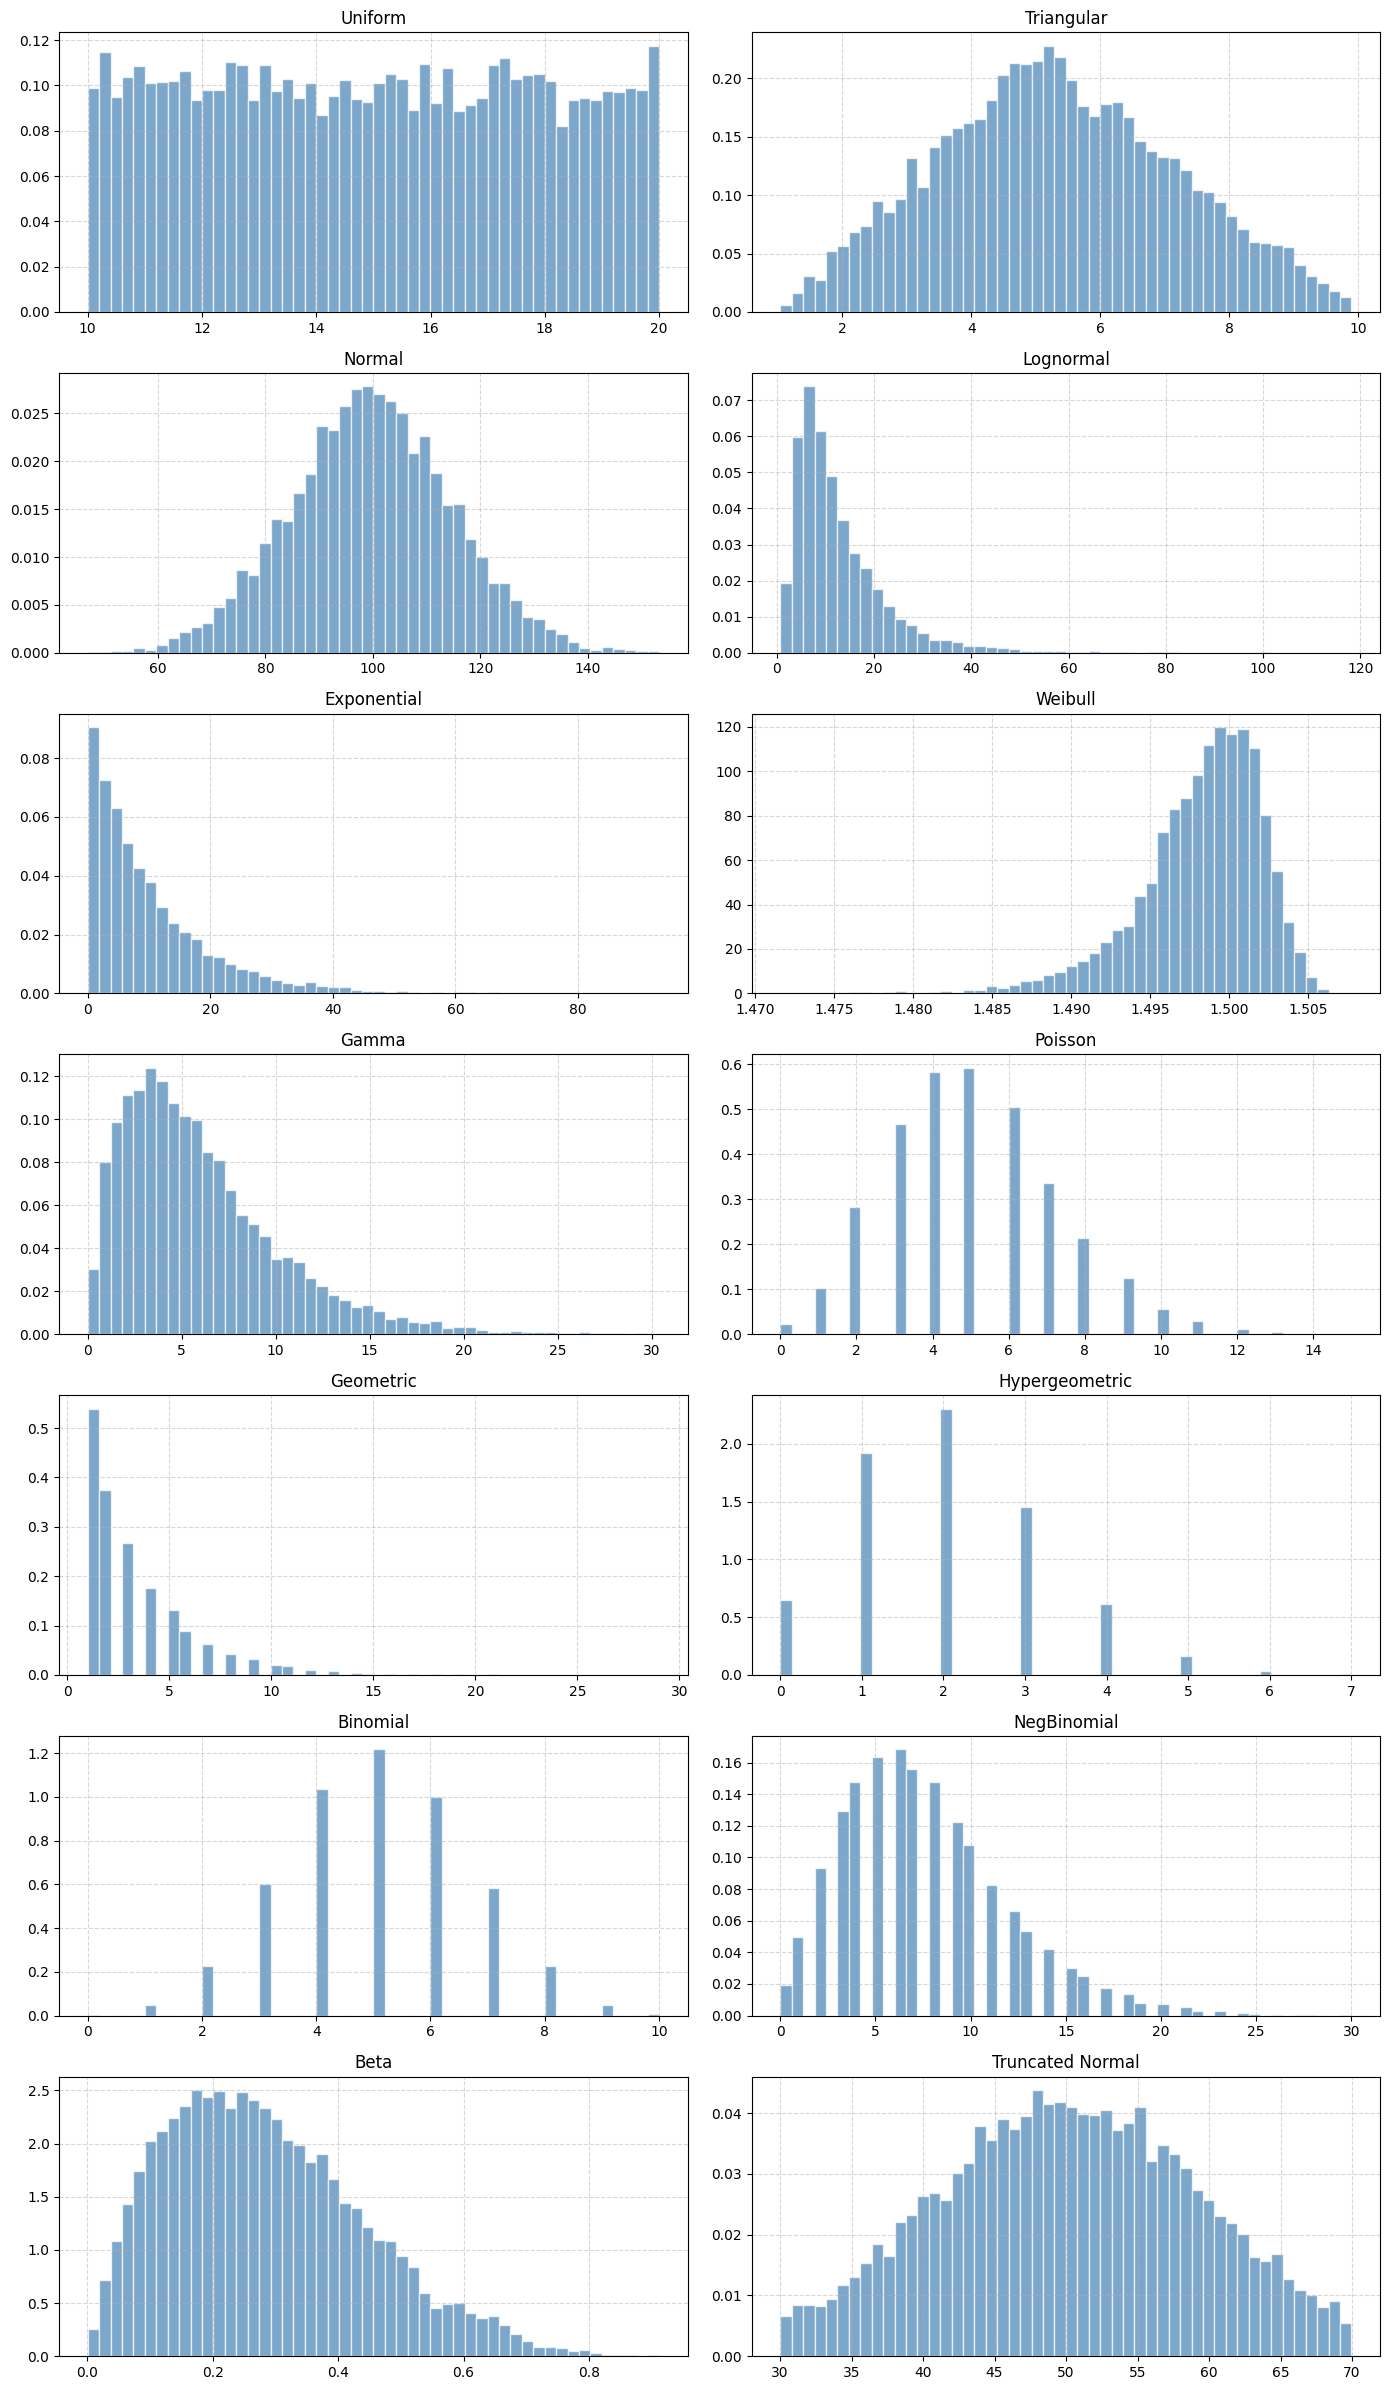

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt

# количество сэмплов
N = 10000

samples = {}

# генераторы из модуля random
samples["Uniform"] = [random.uniform(10, 20) for _ in range(N)]
samples["Triangular"] = [random.triangular(1, 10, 5) for _ in range(N)]
samples["Normal"] = [random.gauss(100, 15) for _ in range(N)]
samples["Lognormal"] = [random.lognormvariate(np.log(10), np.log(2)) for _ in range(N)]
samples["Exponential"] = [random.expovariate(1/10) for _ in range(N)]
samples["Weibull"] = [random.weibullvariate(1.5, 500) for _ in range(N)]
samples["Gamma"] = [random.gammavariate(2, 3) for _ in range(N)]

# генераторы из модуля numpy.random (там их побольше)
samples["Poisson"] = np.random.poisson(lam=5, size=N)
samples["Geometric"] = np.random.geometric(p=0.3, size=N)
samples["Hypergeometric"] = np.random.hypergeometric(ngood=20, nbad=80, nsample=10, size=N)
samples["Binomial"] = np.random.binomial(n=10, p=0.5, size=N)
samples["NegBinomial"] = np.random.negative_binomial(n=5, p=0.4, size=N)
samples["Beta"] = np.random.beta(a=2, b=5, size=N)

# Truncated normal
trunc = []
while len(trunc) < N:
    x = random.gauss(50, 10)
    if 30 <= x <= 70:
        trunc.append(x)
samples["Truncated Normal"] = trunc

# Рисуем все распределения
fig, axes = plt.subplots(7, 2, figsize=(14, 24))
axes = axes.flatten()

for i, (name, data) in enumerate(samples.items()):
    ax = axes[i]
    ax.hist(data, bins=50, density=True, alpha=0.7, color="steelblue", edgecolor='white')
    ax.set_title(name)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


## Генерация категориальных данных

Так как кол-во значений категориальной перемнной счетно и ограничено, подходит только одно распределение: Категориальное
$$\sum_{i \in categories} P_{i} = 1$$

Моделируется оно также достаточно просто:
```
import random
random.choice(['a','b','c'], probs=[0.25, 0.5, 0.25])
```

Если не передавать аргумент probs, то будет просто равномерный случайный выбор из 3 вариантов



# Генерация без референса
---
Кейс, когда данных вообще нет

Тут все относительно просто, выбрать $P_{fake}$ так чтобы оно было похожим на $P_{real}$ можно только экспертно. Разумно искать среди параметрических семейств простых распределений. Простые распределения более универсальные, из них проще сэмплировать и кроме того большинство величин реального мира хорошо моделируются как раз ими (для многих даже есть теоретическое обоснование) 

# Генерация с референсом
---
Кейс, когда датасет с реальными данными есть, но надо определить подходящее под них распределение, чтобы можно было сэмплировать наблюдения аналогичные реальным

"Ленивый" способ:
- посчитать среднее занчение переменной $\overline{X}$ и нагенерировать новых точек вокруг этого среднего
- посчитать среднее $\overline{X}$ и дисперсию $\sigma^2$ переменной и нагенерировать новых точек нормальным распрделением $N(\mu,\sigma)$

Минусы: при таком подходе не учитывается сама распределения, слишком грубая оценка. Реальные распределения могут быть смещенными (skewed), мультимодальными (много пиков) и прочее

### Метод максимального правдоподобия

На практике выбирают какое-то простое параметризованное семейство распределений (например, Нормальные) и подгоняют его параметры (parameter fitting)

В статистике базовый способ подгонки параметров называется __метод маскимального правдоподобия__

Допустим, выбранное нами распределение определяется какими-то параметрами $\theta = (a,b)$, тогда вероятность пронаблюдать имеющуюся совокупность данных $X$ при конкретных значениях $\hat{\theta}$ называется "правдоподобием" (Likelihood). Оптимальный набор параметров - тот, который максимизируют правдоподобие данных. Отсюда название метода

Процесс максимизации правдоподобия может быть аналитическим, может быть итерационным, главное среди всех распрделеений на выходе мы имеем то, которое лучше всего подходит под эти данные

<img src="img/likelihood.png" width=350>

Пример Python кода
```
import pandas as pd
import numpy as np
from scipy import stats

# Данные
np.random.seed(42)
df = pd.DataFrame({"x": np.random.gamma(shape=2., scale=2., size=500)})

# Подгонка распределения (например, Gamma)
shape, loc, scale = stats.gamma.fit(df["x"])

print(f"Gamma params: shape={shape:.3f}, loc={loc:.3f}, scale={scale:.3f}")
```



In [30]:
import numpy as np
import scipy.stats as st

import sdv.datasets.demo

candidates = [
    st.norm,           # Normal
    st.lognorm,        # Lognormal
    st.expon,          # Exponential
    st.gamma,          # Gamma
    st.weibull_min,    # Weibull (минимальный)
    st.uniform,        # Uniform
    st.triang          # Triangular (параметризован через c)
]

ranking = fit_candidates_continuous(x, candidates)
for r in ranking[:3]:
    print(r["dist"], "params=", r["params"], "BIC=", round(r["BIC"], 1))

import matplotlib.pyplot as plt

best = ranking[0]
dist_name, params = best["dist"], best["params"]
dist = getattr(st, dist_name)

xs = np.linspace(min(x), max(x), 400)
plt.hist(x, bins=50, density=True, alpha=0.4, edgecolor="black")
plt.plot(xs, dist.pdf(xs, *params))
plt.title(f"{dist_name} fit")
plt.show()

def fit_and_score(x, dist):
    params = dist.fit(x)
    return {"dist": dist.name, "params": params, "ll": np.sum(dist.logpdf(x, *params))}

results = [fit_and_score(x, d) for d in dists]
return sorted(results, key=lambda r: r["BIC"])


# Faker
---
Часто требуется генерация категориальных данных в соотвествии с паттерном. Стандартов не так много, чем писать свою логику часто проще использовать уже готовую. Faker - бибилотека как раз для этого, это свего рода репозиторий различных генераторов

Примеры использования и упражнения в отдельном файле



# Генерация наборов переменных
---
Кейс, когда мы имеем дело с несколькими связанными переменными<br>Ключевое отличие - между переменными есть __корреляции__

Почему это важно?
Пример набора переменных (рост / вес / возраст). Не учет корреляций этих переменных между собой жаёт завышение вероятности наблюдения комбинаций, в том числе нереальных

Как оценить матрицу ковариаций у набора переменных?
```
sigma = np.cov(X, rowvar=False, bias=False)
```

Как сгенерировать с учетом корреляций

```
# оцениваем первый момент - вектор средних
mu = X.mean(axis=0)                     

# оцениваем второй момент - матрицу ковариаций
sigma = np.cov(X, rowvar=False)

# генерация набора наблюдений
df['new_feature'] = rng.multivariate_normal(mu, Sigma_hat, size=500)
```

#### Зачем учитывать корреляцию

Когда поля датасета независимы, их можно генерировать по-отдельности. В реальности большинство полей скоррелированы, это нужно как-то учитывать

Для примера хотим сгенерировать датасет для моделирования работы фитнес трекера.

Известно, что рост и вес распределены в соотвествии с Нормальным распределением

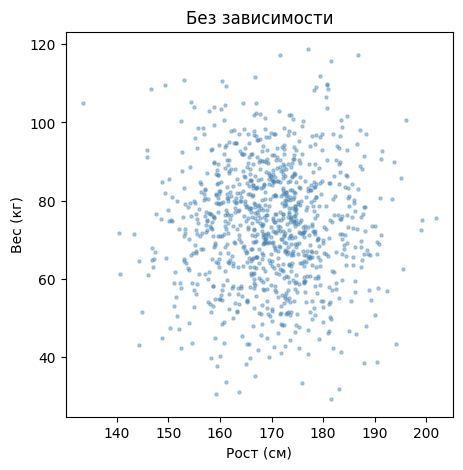

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Генерируем случайные значения
height_ind = rng.normal(170, 10, 1000)
weight_ind = rng.normal(75, 15, 1000)
df_ind = pd.DataFrame({"height": height_ind, "weight": weight_ind})

# Смотрим, что получилось
plt.figure(figsize=(5, 5))

plt.scatter(df_ind["height"], df_ind["weight"], s=5, alpha=0.4, c="steelblue")
plt.title("Без зависимости")
plt.xlabel("Рост (см)")
plt.ylabel("Вес (кг)")

plt.show()

Невворуженным взглядом видно, что датасет изобилует примерами, где при росте 180см вес 40 кг. Хотя в реальности такие примеры долдны быть экстремально редки. 

Можно руками собрать матрицу ковариации через задание корреляции $\rho$, напеример для двумерного случая

Вспоминаем как выглядит корреляция Пирсона

$$Corr(X,Y) = \frac{Cov(X,Y)}{\sigma_x \sigma_y} = \frac{\mathbb{E}(X-\mathbb{E[x]}) \mathbb{E}(y-E[y])}{\sigma_x \sigma_y}$$

Значит ковариация выражается тоже легко 

$Cov(X,Y) = \rho \sigma_x \sigma_y$

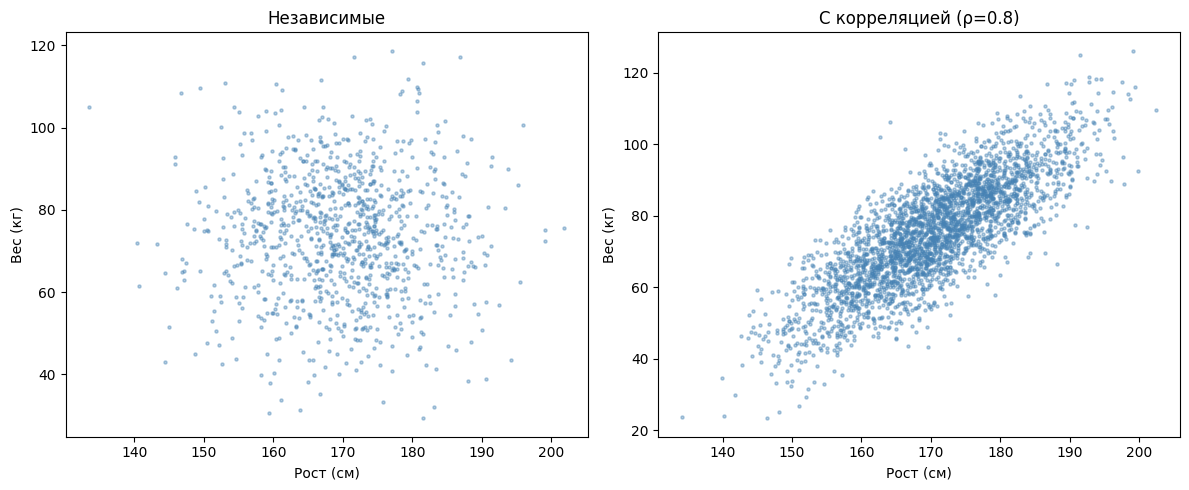

Оценка корреляции Пирсона (слева): -0.008
Оценка корреляции Пирсона (справа): 0.806


In [28]:
# Как исправить
cov = np.array([
    [sd_height**2, rho * sd_height * sd_weight],
    [rho * sd_height * sd_weight, sd_weight**2]
])
mean = [170, 75]
height_corr, weight_corr = rng.multivariate_normal(mean, cov, size=n).T
df_corr = pd.DataFrame({"height": height_corr, "weight": weight_corr})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df_ind["height"], df_ind["weight"], s=5, alpha=0.4, c="steelblue")
axes[0].set_title("Независимые")
axes[0].set_xlabel("Рост (см)")
axes[0].set_ylabel("Вес (кг)")

axes[1].scatter(df_corr["height"], df_corr["weight"], s=5, alpha=0.4, c="steelblue")
axes[1].set_title("С корреляцией (ρ=0.8)")
axes[1].set_xlabel("Рост (см)")
axes[1].set_ylabel("Вес (кг)")

plt.tight_layout()
plt.show()

# --- Проверим корреляции ---
print("Оценка корреляции Пирсона (слева):", df_ind.corr().iloc[0,1].round(3))
print("Оценка корреляции Пирсона (справа):", df_corr.corr().iloc[0,1].round(3))

### Корреляции с категориальной переменной
Пример 1 - разброс зарплат в зависимости от отдела компании<br>
Прмиер 2 - распределение уровня образования в зависимости от региона

Базовый способ: If-then логика

Пример - упражнение на Faker

# SDV
---
Библиотека для генерации синтетики

См. отдельный файл

# Непараметрическая генерация
---
Некоторые подходы к генерации без использования параметризованных распределений 

## Bootstrap
__Идея:__ просто дублируем случайные точки выборки, чтобы сделать её больше (сэмплирование с повторением)

Можно делать генерацию и для всей выборки, не только для границ классов, но полезность такого действия более сомнительная

## KDE (kernel density estimation)
__Идея:__ не делаем предположений о семействе распределения $P_{real}$, а собираем плотность из мини-плотностей одельных наблюдений (такие мини-плотности называют ядрами, kernels)

Наиболее простое ядро - Гауссово

__Плюсы:__ мы можем моделировать распределения произвольной сложности<br>
__Минусы:__ высокий риск уйти в overfitting

Варианты:
- scipy.stats<br>```gaussian_kde(data).resample(n=1000)```<br><br>
- sklearn.neighbors<br>```KernelDensity("Gaussian").fit(data).sample(n=1000)```<br><br>
- руками по CDF<br>один из самых простых способов сэмплирования из произвольного 1D распределения - построить CDF, выбрать случайную точку на u = (0,1) и выбрать x, в которой F(x) = u

## Несбалансированность классов

Как частный случай, задача генерации возникает, когда хотим выравнять неравноммерный баланс классов (наример, 99% vs 1%). Перед этим важно понимать почему считается плохо, когда один класс превалирует в выборке

- Проблема 1: модели не хватает сигнала от "редкого" класса для формирования корректной разделяющей поверхности
- Пробелма 2: влияет на величину метрик типа Accuracy, см. феномен [Accuracy Paradox](https://en.wikipedia.org/wiki/Accuracy_paradox)<br>Решение: использовать более подходящие метрики, например, ROC AUC

## SMOTE
[imbalanced-learn](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.BorderlineSMOTE.html)

__Идея:__ будем генерировать новые точки как линейные комбинации существующих точек. Иными словами, нагенерируем новых точек вокруг реальных 

Чтобы не сломать глобальную струкруту выборки, новые точки будем генерировать только в рамках своего класса (или кластера, далее есть методы). То есть предполагается, что выборка уже размечена под задачу классификации - это объясняет основной use-case метода, выравнивание баланса несбалансированной выборке

__Алгоритм:__<br>для каждой точки $x$ миноритарного класса
1. найти k ближайших соседей этого же класса
2. из этих k соседей случайно выбираем одного $x_{n}$
3. выбираем локацию на отрезке $x_{current} + \lambda (x_{current}-x_{neighbor})$

## Borderline SMOTE
__Идея:__ определяем наблюдения, которые находятся на границе классов и делаем генерацию только для них

## ADASYN
__Идея:__ делаем SMOTE генерацию для миноритарного класса, но ее величину определяем по "сложности" наблюдения

<br><br>
<img src="img/smote_versions.jpeg" width=500>

## SVMSMOTE
__Идея:__ делаем SMOTE генерацию для миноритарного класса, но делаем ее только в окрестности опорных векторов

## ClusterSMOTE
__Идея:__ делаем SMOTE генерацию, но отдельно для кластеров созраняем  глобальную структуру



## Синтетика для обучения языковых моделей (LLM)
Есть примеры LLM моделей, обучаемых преимущественно на синтетических данных

Что требуется от данных для обучения: объем VS разнообразие. Первое досигается легко (дублированием), со вторым посложнее

Подходы:
- self-instruct<br>генерация пар запрос-ответ на основании небольшого seed датасета
- distillation<br>
- data augmentation<br>переформулировки для увеличения ращмеров и разнообразия объема данных
- reasoning traces<br>генерация размышлений
- synthetic code<br>генерация задач и тестов - есть скрипт, сгенерируй 10 упражнений к нему

Некоторые примеры моделей
- Alpaca (Stanford, 2023)<br>идея: большая модель (GPT-3) сгенерировала множество пар запрос-ответ на основании небольшого (175 пар) seed сета, далее малая модель была дообучена на этих парах<br><br>
- Vicuna, WizardLM<br>так же, но с GPT-4 диалогами<br><br>
- Orca<br>обучалась на сгенерированных reasaoning traces от GPT-4<br><br>
- LLAMA 2<br>пишут что смешивали human и generated инструкции<br><br>
- Phi<br><br>
- Gemini


# Генерация с помощью LLM
---
Подход, ставший возможным с развитием языковых моделей, и не требующий никаких дополнительных телодвижений: промпт "сгенрируй мне таблицу синтетических данных из 1000 строк"

Плюсы:
1. быстро
2. у сети есть апроиорные знания о свйоствах некоторых объектов (рост пингвинов, стоимость квартир и т.д.)

Минусы:
1. если нужна детальная спецификация данных, описывать все ограничения текстом в промпте может быть не быстрее, чем сгенерировать самостоятельно
2. нет гарантии результата: сети галлюцинируют. пользователи плохо пишут запросы
3. разные решения при каждом запуске
4. под капотом пишется тот же Python код для генерации. Воспользоваться мощьностью моделью, например, для генерации текстовых отзывов не получится (либо несколько примеров, либо цикл запросов к модели)

# Evaluation
---
После генерации нужно оценить качество данных. Большое кол-во метрик, ниже некоторые подходящие примеры. Условно можно разделить на две группы: fidelity (правдоподобие), utility (полезность)

## Fidelity
Насколько синтетика «похожа» на реальность<br>Сравнивать можно всё что угодно: различные моменты распределений, сами распределения, корреляционную структуру, пропуски данных

- Marginals - статистики по отедльным переменным.
  - Kolmogorov-Smirnov тест для непрерывных признаков<br>(наибольшая разница при сравнении двух CDF)
  - критерий согласия $\chi^2$ для категориальных фичей
  - добавить стратификацию по важным срезам (например, регион, пол)<br><br>

- Корреляции между парами признаков:
  - Корреляции Пирсона/Спирмена - стандартный коэффициент ассоциированности пары <u>числовых</u> фичей<br>$Corr(X,Y) = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}$<br><br>
  - Cramér’s V - коэффициент зависимости пары <u>категориальных</u> фичей<br>$V(X,Y)=\frac{\phi}{\sqrt{shape}} = \sqrt{\frac{\chi^2}{n \cdot shape}}$<br><br>
  - Mutual Information - коэффициент зависимости пары произвольных случайных переменных<br>$MI(X,Y)=\int_X \int_Y P(x,y) \,\, log{\frac{P(X,Y)}{P(X) P(Y)}}$<br><br>
  - сравнение тепловых карт корреляций наборов фичей (real vs synthetic)<br><br>

- Многомерное сходство
  - Wasserstein Distance (Earth Mover’s Distance): сколько «массы» нужно «перенести», чтобы из реального распределения получить синтетическое; хорошо детектирует сдвиги<br><br>
  - Energy Distance: насколько расстояния между выборками (inter-sample distance) больше расстояния внутри выборок (intra-sample distance)<br>$\widehat{\mathcal{E}}
= \frac{2}{nm}\sum_{i=1}^{n}\sum_{j=1}^{m}\|x_i - y_j\|
- \frac{1}{n^2}\sum_{i=1}^{n}\sum_{i'=1}^{n}\|x_i - x_{i'}\|
- \frac{1}{m^2}\sum_{j=1}^{m}\sum_{j'=1}^{m}\|y_j - y_{j'}\|
$<br><br>
  - Classifier Two-Sample Test (C2ST): обучаем классификатор «real vs. synthetic»<br>AUC≈0.5 — хорошо (неотличимы), выше — заметимые артефакты<br><br>
  - Сравнивать real vs fake распределения можно с позиции классификации - покрытие vs плотность, recall vs precision
    - низкий recall может говорить о схлопывании генерируемого сигнала<br>(эффект Mode Collapse часто имеющий место при использовании GAN сетей для генерации)<br>
    - низкий precision — перебор с нерелевантными примерами<br><br>
  - MMD (Maximum Mean Discrepancy): TBD<br><br>

### Business rules
Проверки допустимых диапазонов, кросс-полей (логические ограничения), уникальности ключей, распределения пропусков, совместной встречаемости категорий

Для временных рядов: сравнение ACF/PACF, сезонности, спектральной плотности

Для реляционных/многотабличных данных: согласованность ключей, кардинальности связей, графовые степени

## Utility
полезность для downstream задач

- TSTR («Train on Synthetic, Test on Real»): обучаем модель на синтетике, тестируем на реальном hold-out; сравниваем метрики с «Train/Test на реальном».
- Смешанные трейны. Строим кривую полезности по доле синтетики в трейн-сете (0→100%) и смотрим, где метрика деградирует/улучшается. Полезно фиксировать архитектуру/гиперпараметры и давать доверительные интервалы (бутстрэп).
- Ширина задач. Проверяйте не одну задачу, а несколько (классификация/регрессия/ранжирование), плюс калибровку вероятностей и стабильность к сид-перемешиваниям.
- Фэйрность/сдвиги. Если релевантно — метрики справедливости на синтез-тренированных моделях и Population Stability Index (PSI) между real train / synthetic / real test.

__Privacy__ = риск утечки оригиналов

Ближайший сосед и дубликаты. Регистрируйте распределение дистанций до NN от реальных к синтетическим; «аномально близкие» — красный флаг. Ловите точные/приблизительные дубликаты (LSH/MinHash, кластеризация по эмбеддингам).

Membership inference (концептуально). Атакующий пытается по объекту и отклику модели понять, был ли объект в трейне. Высокая точность/ AUC такой атаки ⇒ риск меморизации.

Attribute inference / linkage. По квази-идентификаторам можно «достроить» скрытые поля или смэтчить записи с внешними источниками; оценивайте уникальности по квази-ID, k-анонимность/k-map, l-diversity/t-closeness, вероятность правильной линковки.

DP-гарантии (если применимо). Если генератор обучался с дифференциальной приватностью — явно указывайте бюджет (ε, δ) и трактуйте его вместе с эмпирическими тестами выше.

Правило панели метрик = не полагаться на одну цифру. Делайте контрольные базelines: 
(а) real-vs-real (две подвыборки реального) — ваша «нижняя граница» различий; 
(б) real-vs-synthetic — целевой разрыв. Всегда давайте интервалы неопределённости (бутстрэп), учитывайте размер выборки и страты.

Что ещё добавить в чек-лист:
- Multiscale KS/EMD по срезам (по группам пользователей, редким категориям)
- Mutual Information матрица и её MAE к реальной
- Проверяем на выбросы (Outlier-поведение)<br>доля/типология выбросов и «хвосты» распределений
- Проверяем на заполненность полей:
  - MCAR: случайный пропуск
  - MAR: Missing-At-Random не зависит от реального значения признака
  - MNAR: Missing not at random зависит от реального значения признака
  - совместная пропущенность полей
- C2ST-диагностика<br>Строим классификатор «real vs synthetic» и оценить по нему "важность" всех признаков. Признаки с высоким feature importance - слабое место генерации
- Валидация доменных ограничений как автоматизированные тесты (unit-тесты на данные)

Возможный вариант отчётности: дашборд с (1) маржиналами, (2) зависимостями, (3) многомерной метрикой (MMD/EMD/C2ST), (4) utility-кривой, (5) privacy-панелью (NN-дистанции, дубликаты, MI-AUC), плюс короткий вердикт и риски





### Wasserstein distance
[[paper]](https://en.wikipedia.org/wiki/Earth_mover%27s_distance)

EMD = Earth Movers Distance или Wasserstein distance

__Идея:__ если рассматривать веротяностное распределение буквально, как горку песка, распределенную на поверхности, то расстояние между двумя горками P и Q можно задать, как минимально возможная работа, которую нужно совершить с первой горкой, чтобы две горки стали одинаковыми. Здесь работа - это перевозка некоторого кол-ва песка $\gamma(i,j)$, зависит от массы песка и расстояния $d(x_i, j_i)$, на которое нужно перевозить

$$
W(P, Q) = \inf_{\gamma \in \Gamma(P, Q)} 
\sum_{i,j} \gamma(i,j) \cdot d(x_i, x_j)
$$

$\Gamma$ - множество всех возможных перемещений. Решается оптимизационная задача

Одна из областей применения - оптимизация транспортной логистики. Там возникают много похожих задач.

Метрика хорошо моделирует сдвиги распределений - если, например, подвинули на 0.5, то значение метрики будет ровно 0.5. Поскольку мы просто перенесли единичную массу на расстояние d

<img src="img/emd1.png">

Напоминает метрики редакторского расстояния ([[edit distance]](https://en.wikipedia.org/wiki/Edit_distance)) между строками P и Q, которые тоже определяется через кол-во работы - необходимое для перевода P к виду Q

Особо полезен в обучении GAN-ов
[[paper]](https://arxiv.org/abs/1701.07875)




# Generative Adversarial Networks (2014)
---
[[paper]](https://arxiv.org/pdf/1406.2661)

Генеративные сети = сети, которые на выходе выдают случайно сгенрированный образ (картинка, текст, временной ряд). Образ должен быть достаточно случайным, чтобы быть уникальным, но при этом быть неотличимым от реальных данных. В идеале как можно точнее смоделировать распределение образов

Генеративные модели 

GAN (генеративные соревнующиеся сети) - подход, появившийся в 2014 году после выхода статьи GoodFellow и Bengio. Подход стал SOTA решением в области генеративного моделирования на следующие неcколько лет. Для домена Computer Vision это как минимум период с 2014 по 2018 год, пока не появились диффузионки. А для некоторых других доменов вполне используются и сейчас

Что было до: energy-based models, RNNs, Autoencoders, 

__Идея:__ есть сеть называемая "генератором", задача которой возвращать случайный сгенерированный образ. В качестве регуляризатора для нее используется другая сеть, которая называется "дискриминатором". Ей ничего не известно про генератор, но её задача распознавать плохо сгенерированные образы, предсказывая настоящий это сигнал или фейковый

Тогда решение представляется как антогонистическая игра генератора и дискриминатора. Имея real и fake примеры, дискриминатор ищет кодировку входного сигнала D(x), которая бы больше "разводила" по сторонам эти два класса и тем самым снижала ошибку предсказания. Генератор же пытается генерировать такие примеры, чтобы они попадали в те области, где дискриминатор оценивает наблюдаемые образы как реальные. Равновесное решение этой игры ($D^*$,$G^*$) соотвествует оптимальной настройке генератора, когда дискриминатор перестает отличать фейковые генерации от настоящих данных. Оптимизируется целевая функция V(D,G)

$$
\min_G \max_D \; V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}} \big[ \log D(x) \big] + \mathbb{E}_{z \sim p_z} \big[ \log (1 - D(G(z))) \big]
$$

__Интерпретация:__ для "реальных" примеров дискриминатор D максимизирует средний логарифм вероятности реальных данных $D(x)$, а для сгенерированных примеров максимизирует логарифм вероятности, что это фейковые данные 1 - D(G(z)). С другой стороны, генератор стремится  минимизировать этот штраф за фейковые данные, делая их более качественными

Архитекутура получила развитие в области CV и стала SOTA решением в период с 2015 по 2020 года

Случайный шум моделирует разнообразие $z ~ N$, сеть-генератор G() переводит его в распределение $p_{model} = G(z)$. Дискриминатор 

<img src="img/gan1.png" width=500>

Алгоритм обучения GAN:
1) <u>update дискриминатора</u>
    - генератор создает батч случайных "фейковых" данных
    - дискриминатор сэмплирует батч случайно выбранных "реальных" данных из обучающей выборки
    - они объединяются в один датасет и помечаются как 0 и 1 соотвественно
    - он прогоняется через дискриминатор и тот возвращает предикт вероятности реальных данных $D(x) = P(real|x)$ 
    - считаем кросс-энтропийный лосс на выходе дискриминатора<br>$
    L_D = \mathbb{E}_{x \sim p_{data}} \big[ \log D(x) \big] \;+\; 
    \mathbb{E}_{z \sim p(z)} \big[ \log (1 - D(G(z))) \big]
    $<br>на реальных данных выход дискриминатора P должен быть близок к 1.0, а на фейковых данных близок к 0.0
    - веса генератора фиксируются и мы оптимизируем только дискриминатор<br>таким образом он учится отличать реальные образы от сгенерированных<br><br>
2) <u>update генератора</u>
    - генератор создает батч случайных фейковых данных
    - считаем лосс<br>$L_G = \mathbb{E}_{z \sim p(z)} \big[ \log (1 - D(G(z))) \big]$<br>интерпретация сгенерированные данные 
    - дискриминатор замораживается и мы оптимизируем генератор<br>он учится генерировать так чтобы дискриминатор дал высокую оценку - не смог отличить от реальных данных<br><br>

### Теория

Последовательно обучая сеть, мы постепенно сводим распределение генерируемых данных $P_{model}$ к распределению реальных данных $P_{real}$. Качество дискриминатора при этом будет ухудшаться, стремясь к вероятности 1/2

<img src="img/gan2.png" width=500>

### Дискриминатор

Из постановки задачи видно, что на обоих шагах оптимизируется один и тот же функционал $V(D,G)$. Разница лишь в том, но на первом шаге зафисирован $G$, а на втором $D$. Кроме того

Функция потерь дискриминатора не что иное, как бинарная кросс-энтропия:<br>
$
L_D = - \mathbb{E}_{x \sim p_{\text{data}}} \, \log D(x) - \mathbb{E}_{z \sim p_z} \, \log \big(1 - D(G(z))\big)
$

Возможно не совсем интуитивно, почему это кросс-энтропия - там и суммы по разным распределениям идут, ещё и вход разный D(x) D(G(x)). Ниже объяснение

Напомним, что бинарная кросс-энтропия $L^{CE}$ (расстояние между $P_{pred}$ и $P_{real}$) выглядит так:<br>
$L^{CE} = - \sum_{pos} \log (P) + \sum_{neg} \log (1-P)$

Или, если занести под одну сумму<br>
$L^{CE} = - \sum \bigg( [y=\text{neg}] \cdot \log{(1-P)} + [y=\text{pos}] \cdot \log{(P)}) \bigg)$

В GAN-ах в роли двух классов выступают $\text{fake}$ и $\text{real}$:<br>
$L = - \sum \bigg( [y=\text{fake}] \cdot \log{(1-D)} + [y=\text{real}] \cdot \log{(D)}) \bigg)$

Выход дискриминатора (по своему построению) это всегда вероятность $P(real)$, а пришел сигнал из батча фейковых данных или батча настоящих не важно

### Генератор
На втором шаге оптимизации (генератора $G$) дискриминатор зафиксирован $D$, поэтому первое слагаемое можно выкинуть:

$$
L_G^{\text{minimax}} = \mathbb{E}_{z \sim p_z}\big[\log(1 - D(G(z)))\big]
$$

У такого обучения есть один минус: если нарисовать функцию поетрь, то при значениях $D=0$ (генериатор рисует плохо) производная равна -1. С учетом того, что градиент распадается на произведение более мелких градиентов, они могут получиться тченб маленькими и процесс будет сходиться неопрадванно долго

__Идея:__ поменять функцию потерь на сонаправленную, но чтобы производная была побольше

$$
L_G^{\text{non-saturating}} = - \mathbb{E}_{z \sim p_z}\big[\log D(G(z))\big]
$$

Поэтому авторы вводят так называемый non-saturarted loss. Решение то же, но сходится быстрее, так как меньше тупит на начальном этапе обучниея генератора

<img src="img/gan_trick.png" width=500>

### Связь с JS дивергенцией

У оптимизируемого функционала $V(D,G)$ есть более короткая форма записи - через одну функцию, через JSD (Jensen-Shannon дивергенцию).

Напомним, что это такое. JSD дивергенция - это симметричный вариант KL дивергенции. Принцип тот же$$
\text{JSD}(p_{\text{data}} \| p_g) =
\tfrac{1}{2}\text{KL}(p_{\text{data}} \| m) +
\tfrac{1}{2}\text{KL}(p_g \| m)
$$

Согласно постановке задачи, мы максимизируем сумму Cross-entropy loss на нашем наборе из реальных и фейковых примеров:<br>
$
p_{\text{data}}(x)\,\log D(x) + p_{fake}(x)\,\log (1 - D(x)) \rightarrow \max
$

Здесь $P_{data}$ и $P_{fake}$ это априорных вероятностей, а D(x) это правдоподобия P("real"|x)

Необходимое условие оптимальности дискриминатора $D$ выражаем через производную<br>
$
\nabla L = \frac{p_{\text{data}}(x)}{D(x)} - \frac{p_g(x)}{1 - D(x)} = 0
$

То есть для любого генератора G дискриминатор будет оптимален, когда вероятность реальных данных равнра<br>
$
D^*(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}
$

Далее можно это учловие подставить в основное выражение:<br>
$
V(D^*, G) =
\int p_{\text{data}}(x) \log \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)} \, dx
+ \int p_g(x) \log \frac{p_g(x)}{p_{\text{data}}(x) + p_g(x)} \, dx
$

Если обозначим знаменатель за $2m(x)$, то первое слагаемое:<br>
$
\log \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}
= \log \frac{p_{\text{data}}(x)}{2 m(x)}
= \log \frac{p_{\text{data}}(x)}{m(x)} - \log 2
$

А второе:<br>
$
\log \frac{p_g(x)}{p_{\text{data}}(x) + p_g(x)}
= \log \frac{p_g(x)}{m(x)} - \log 2
$

И суммарно преобразуется в следующее вырадение:<br>
$
V(D^*, G) =
\text{KL}(p_{\text{data}} \| m) + \text{KL}(p_g \| m) - 2 \log 2
$

Jensen-Shahnnon divergence - это симметричная модификация дивергенции Кульбака-Либлера<br>
$
\text{JSD}(p_{\text{data}} \| p_g) =
\tfrac{1}{2}\text{KL}(p_{\text{data}} \| m) +
\tfrac{1}{2}\text{KL}(p_g \| m)
$

Тогда оптимизируемую функцию $V(D,G)$ можно выразить явно через JSD<br>
$
V(D^*, G) = -\log 4 + 2 \cdot \text{JSD}\!\big(p_{\text{data}} \,\|\, p_g\big)
$

## Training chanllenges and Mode Collapse
Из документации PyTorch:<br>
"Be mindful that training GANs is somewhat of an art form, as incorrect hyperparameter settings lead to mode collapse with little explanation of what went wrong..."

Некоторые хаки перечислены здесь: https://github.com/soumith/ganhacks

При обучении GAN-ов делается двухшаговая минимаксная оптимизация. Это не стандартная Loss minimiztion, у неё нет гарантий сходимости, плюс есть целый ряд негативных эффектов, собирательно называемых "training instability"

Поэтому говорят, что обучать GANы очень трудно. Это в том числе объясняет появление многочисленных модификаций в семействе GAN методов - все они призваны каким-то образом улучшить стабильиность обучения

Какие проблемы:
- нет гарантии сходимости
- малые градиенты
- Mode Collapse
- дискриминатор
- 











# DCGAN
---

[[paper]](https://arxiv.org/abs/1511.06434?utm_source=chatgpt.com)

DCGAN = Deep Convilutional GAN

Они одними из первых применили GAN подход для генерации картинок на базе CNN архитекутуры (и генератор, и дискриминатор реализуются CNN сетями) и достигли достойных результаты на небольших картнках.

Что было до этого: VAE, Energy-based models, HMMs, PixelRNN и т.д.<br>
Какие модификации были после: CycleGAN (2017), BigGAN (2018) от DeepMind, StyleGAN (2019) от Nvidia

<img src="img/dcgan.png" width=500>

Ключевые фичи модели DCGAN:
- свертки
- обучаемый пулинг (upsampling/downsampling)
- BatchNorm для борьбы с Mode Collapse
- ReLU, LeakyReLU
- FCN?



Принцип работы генратора: сеть должна научиться мапить простое распределение (шум как правило делают нормальным) в выученное распределение данных

Ответ дискриминатора: эта картинка больше похожа на то, что я видел в реальных данных, или на то, что пришло от генератора

# Conditinal GAN
---
[[paper]](https://arxiv.org/abs/1411.1784)

CGAN = conditional GAN

Two challenges:
- Gradient vanishing
- Mode collapse

# Other GAN variants
---
https://arxiv.org/pdf/1711.10337

Здесь есть неплохой обзор модификаций к типовому подходу

Подходы можно объединить:
1. смягчение функции дискриминатора
2. расширение распределений

# WGAN (2017)
---
[[paper]](https://arxiv.org/pdf/1701.07875)

WGAN = Wasserstein GAN

__Идея:__ вместо нестабильно сходящейся кросс-энтропии, будем оптимизировать расстояние Вассершейна (точнее приближенный его вариант разницу между матожиданиями). Такое расстояние лучше оптимизируется, так как градиенты всегда адекватной величины

Архитектура точно такая же, как vanilla GAN кроме следующих изменений:
- дискриминатор теперь вместо вероятности возвращает логиты, просто некий скор $f(x) in \mathrm{R}$ и называется "критиком" (Critique)<br>название выбрано так как "дискриминатор" делает выбор в пользу одной из двух альтернатив $(p, 1-p)$, а "критик" - просто даёт оценку $f(x) \rightarrow score$
- выход модели-критика делаем гладким: добавляем условие на k-Липшицовость<br>это необходимо, так как выход модели-критика теперь ничем не ограничен и может "улетать" в бесконечность 
- вместо кросс-энтропии (интеграла "несоотвествия" вероятностей) в качестве целевой функции используем <u>расстояние Вассерштейна</u><br>важно - не саму меру, а её  аппроксимацию
- Gradient Penalty
- Conditional Statement

__Wasserstein Distance__ aka __Earth Movers distance__ = сколько работы нужно совершить, чтобы "перетащить" одно распределение в другое. В отличие от кросс-энтропии такое расстояние учитывает положение двух плотностей друг относительно друга, поэтому до полной сходимости расстояния градиент всегда будет ненулевым

### Алгоритм

Параметры алгоритма:<br>
$\alpha = 0.00005$: learning rate<br>$c = 0.01$ величина клиппинга (мин/макс допустимые значения весов)<br>$m=64$ - размер батча для обучения<br>
$n_{critic} = 5$ кол-во обрабатываемых батчей для каждой итерации обучения модели-критика<br>
$w_0$ = начальная инифиализация модели критика<br>
$\theta_0$ = начальная инифиализация модели генератора

1. **while** $ \theta $ has not converged **do**  
2. &emsp;**for** $ t = 0, \ldots, n_{critic} $ **do**  
3. &emsp;&emsp;Sample $ \{x^{(i)}\}_{i=1}^m \sim \mathbb{P}_r $ a batch from the real data
4. &emsp;&emsp;Sample $ \{z^{(i)}\}_{i=1}^m \sim p(z) $ a batch of prior samples
5. &emsp;&emsp;$ g_w \leftarrow \nabla_w \Big[ \tfrac{1}{m} \sum_{i=1}^m f_w(x^{(i)}) - \tfrac{1}{m} \sum_{i=1}^m f_w(g_\theta(z^{(i)})) \Big] $  
6. &emsp;&emsp;$ w \leftarrow w + \alpha \cdot RMSProp(w, g_w) $  
7. &emsp;&emsp;$ w \leftarrow clip(w, -c, c) $  
8. &emsp;**end for**  
9. &emsp;Sample $ \{z^{(i)}\}_{i=1}^m \sim p(z) $ a batch of prior samples.  
10. &emsp;$ g_\theta \leftarrow - \nabla_\theta \tfrac{1}{m} \sum_{i=1}^m f_w(g_\theta(z^{(i)})) $  
11. &emsp;$ \theta \leftarrow \theta - \alpha \cdot RMSProp(\theta, g_\theta) $  
12. **end while**

### Теория
Важное свойство расстояния Вассерштейна - есть такой принцип __дуальности Канторовича-Рубиншетйна__, по которому расстояние Вассерштейна между двумя распределениями 

$$W(\mathbb{P}_r, \mathbb{P}_g) = \inf_{\gamma \in \Pi(\mathbb{P}_r, \mathbb{P}_g)} \mathbb{E}_{(x,y) \sim \gamma} \big[ \|x - y\| \big]$$

может быть хорошо аппроксимировано разницей $f(x)$ на матожиданиях этих распределений (с добавлением требования ограниченности таких функций), что сильно упрощает расчет

$$W(\mathbb{P}_r, \mathbb{P}_\theta) = \sup_{\|f\|_L \leq 1} \mathbb{E}_{x \sim \mathbb{P}_r}[f(x)] - \mathbb{E}_{x \sim \mathbb{P}_\theta}[f(x)]$$

*Канторович в 1930е изучал трансопртную экономику, в том числе описывал метрику Вассерштйена

Принцип требует чтобы рассматривалось не любые, а множество 1-Липшиц ограниченных функций

Из матанализа помним, что липшицовой функцией называется такая функция, что $$|f(x) - f(y)| < |x-y|$$. То есть это функции с ограниченной вариативностью. Интерпретация: для любого квадрата со стороной $\delta x$ значения функции не выходят за его границы.

1-липшицевость модели-критика реализуется примитивным способом - с помощью клиппинга <u>всех</u> весов критика $w_{i,j}$: после очередного апдейта на шаге backpropagation ставшие слишком большими (по модулю) веса обрезаются по лимитирующим значения $$w = clip(w, -c, c)$$

Форма функционала не случайна. Это хорошо изученный в статистике класс метрик, называемый [Integral Probability Metrics](https://en.wikipedia.org/wiki/Integral_probability_metric). Расстояние Вассерштейна - один из наиболее известных примеров

$$d_{\mathcal{F}}(\mathbb{P}_r, \mathbb{P}_\theta) = \sup_{f \in \mathcal{F}} \mathbb{E}_{x \sim \mathbb{P}_r}[f(x)] - \mathbb{E}_{x \sim \mathbb{P}_\theta}[f(x)]
$$

В качесвте Evaluation процедуры авторы сравнили свой подод с более классическим $DCGAN$ на задаче генерации картинок. В случае с WGAN не было примеров mode collapse

#### Преимущества подхода Wasserstein GAN
Авторы выделяют два:
- интерпретируемость функции потерь
- стабильная сходимость

##### Интерпретируемость

Под интерпретируемостью здесь понимается корреляция с визуальным качеством генерации. Чуть-чуть плохие генерации должны иметь меньшее растояние, чем совсем мусорные

Ниже пример обучения дискриминатора по GAN - JS дивергенция. Видно, что её значения ничего не говорят о качестве генерации
<img src="img/wgan_perf_1.png" width=400>

Для сравнения ниже обучение модели-критика по WGAN. Видно, что есть очевидная корреляция с качеством картинки
<img src="img/wgan2.png" width=400>

##### Стабильность обучения

Здесь стабильность = частота сходимости обучения. Утверждается что почти полностью исчезает mode collapse.

<img src="img/wgan1.png" width=400>




# WGAN-GP
---
https://arxiv.org/abs/1704.00028

# DRAGAN (2017)
---
https://arxiv.org/pdf/1705.07215

# CRAMER (2017)
---
https://arxiv.org/abs/1705.10743

# CWGAN-GP (2017)
---
https://cameronfabbri.github.io/papers/conditionalWGAN.pdf

# LSGAN
---
[[paper]](https://arxiv.org/abs/1611.04076)

LSGAN = Least suqares GAN

__Идея:__ для лучшей обощаемости заменяем вероятности на логиты (скор $o(x) \in \mathbb{R}$), а оптимизируемую функцию потреь с CE на MSE

<img src="img/lsgan.png" width=500>

# GAN-GP
---
Идея штрафуем за слишком большой градиент

# Spectral Normalization
---
При обучении ограничиваем спектральную норму матрицы весов

# ACGAN (2017)
---
[[paper]](https://arxiv.org/abs/1610.09585)

AC-GAN = Auxiliary Classifier

__Идея:__ берем CGAN, но добавляем в дискриминатор добавляем ещё одну голову - классификатор класса 

Мотивация: дискриминатор учится не только детектировать “фейк”, но и выделять дискриминативные признаки классов - это улучшает оценку генераций

<img src="img/acgan1.png" width=500>

# InfoGAN (2016)
---
[[paper]](https://arxiv.org/abs/1606.03657)

# SGAN
---
SGAN = stacked GAN

[[paper]](https://arxiv.org/abs/1612.04357)



- Cross-DomainGAN
  - CycleGAN

# BigGAN (2017)
---
__Идея:__ масштабирование GAN обучения для генерации картинок с целью улучшения качества

Архитектурно это ACGAN, но добавлено несколько фичей. В том числе shared embedding.

Фичи:
- Spectral Normalization (SN)<br>идея: нормализуем все слои собственным числом матрицы $W$<br>
Применяется ко всем слоям дискриминатора и генератора<br>
Контролирует Lipschitz-константу, предотвращает градиентный взрыв/коллапс

- Orthogonal Regularization<br>
Доп. регуляризация весов генератора: поощряет ортогональность строк весовых матриц<br>
Идея — уменьшить корреляцию фичей, улучшить разнообразие

- Skip-z (z injection)<br>
Латентный вектор 𝑧<br>
z подаётся не только в первый слой, но инжектится в несколько слоёв генератора (через конкатенацию/условную нормализацию)<br>
Улучшает использование латентного пространства

- Shared Embeddings для class conditioning<br>
В BigGAN условная генерация по классам (ImageNet → 1000 классов)
Вместо отдельных эмбеддингов → используют shared embedding: один общий embedding-вектор, скалируется под конкретный класс
Снижает параметры и улучшает обобщение

- Truncation Trick<br>
При генерации: семплы берутся не из полного Normal(0,1), а из «усечённого» распределения (отсечение крайних значений)
Итог: изображения становятся чище/реалистичнее, но менее разнообразные
Большие батчи (до 2048)
Ключевой инженерный приём: обучали на огромных батчах, что дало более стабильные градиенты
Требует много GPU (TPU v3 pods)

- Huge capacity (большие сети)<br>
Увеличили ширину/глубину слоёв генератора и дискриминатора
Показали: «чем больше сеть, тем лучше качество», если есть правильная регуляризация

- Orthogonal init + careful learning rates<br>
Правильная инициализация (ортогональная) + отдельные lr для G и D

# Tabular GANs
---

CTGAN (2019)
---
[[paper]](https://arxiv.org/pdf/1907.00503)

Успех GAN-ов заставил адаптировать к работе с табличными данными. Однако обычная GAN архитектура не очень подходит для работы с таблицами 

Проблемы табличных данных, которые ухудшают генерацию:
- переменные разных типов (числовые и категориальные)
- в отличие от картинок, часто негауссовы переменные (сложные распределения)
- мультимодальные переменные (несколько пиков в распределении)
- one-hot представления
- несбалансированные категории<br>редкие категории не сильно влияют на loss, поэтому дискриминатор не уделяет им внимание

__Mode specific normalization:__<br>Давайте будем считать все числовые переменные мультимодальными и моделировать смесью распределений. Тогда каждое значение можно закодировать двумя числами: номер смеси и z-score относительно этой смеси

__Train by sample__<br>
- выбирается категориальная переменная (случайно)
- выбирается конкретная категория (пропорционально частоте)
- строится conditional vector
- он конкатенируется со случайным шумом и подается на вход в генератор
- помимо штрафа за непохожесть отдельно штрафуем, если не 

<img src="img/ctgan.png" width=500>

Они ввели методолгию оценки:
1. likelihood
2. 

# CTABGAN (2022)
---
[[paper]](https://arxiv.org/pdf/2102.08369)

- classifier
- mixed types



<img src="img/ctabgan.png" width=1000>

# CTABGAN+
---
[[paper]](https://arxiv.org/abs/2204.00401)


CasTGAN (2023)
---
[[paper]](https://arxiv.org/abs/2307.00384)

For each variable:
  use a separate generator and separate AC (auxiliary classifier)

# Time Series GANs

TimeGAN (2019)
---
Time-series Generative Adversarial Networks

https://papers.nips.cc/paper/2019/file/c9efe5f26cd17ba6216bbe2a7d26d490-Paper.pdf

DoppleGANger
---
https://dl.acm.org/doi/pdf/10.1145/3419394.3423643

# Simple methods
---

#### 1) Bootstrap & Permutation

__Идея:__ повторно семплировать имеющиеся строки/значения, иногда с лёгким сглаживанием, чтобы сохранить маргинальные распределения.

Варианты:
- Row Bootstrap<br>семплируем строки с повторением<Br>pros: сохраняет все совместные зависимости, cons: может дублировать редкие записи → privacy-риск<br><br>
- Stratified Bootstrap<br> то же, но по стратам (класс/сегмент) с сохранением долей<br><br>
- Column Permutation<br>новые наблюдения получаются путем перемешиваем значений столбца (по всей таблице или внутри некоторых групп)<br>перемешивание значений ломает зависимости между признакакми<br>если делаем в рамках групп, то ломает существенно меньше меньше<br><br>
- Swap Noise<br> выбираем пары строк и обмениваем значения в выбранных столбцах <br>pros: гарантированно остаемся в домене переменной мягкий «джиттеринг»<br><br>
- Smoothed Bootstrap<br>комбинация row bootstrap + небольшой джиттер числовых признаков<br><br>

Для приватности избегайте чистого Row Bootstrap на «малых» наборах: добавляйте smoothed/jitter или downweight редкие записи.

#### 2) Jittering (добавление шума)

__Идея:__ генерируем новые точки путем добавления небольшого шума

Опции для числовых признаков:
- Gaussian Jitter<br>$x' = x + ε, ε ~ N(0, σ²)$, где $σ = k·MAD$ или $k·IQR/1.349$, обычно k ∈ [0.01, 0.1]<br><br>
- Laplace Jitter<br>более «тяжёлые хвосты», полезно при лапласовских шумовых моделях<br><br>
- Quantile-aware Jitter<br>шум в процентах от значения (лог-шкала для положительных величин)<br><br>
- Boundary-aware<br>обрезаем все выходящие за допустимые рамки значения шума (clipping); для целых может применяться округление round<br><br>

Опции для категорийных признаков:
- Flip-noise<br>с небольшой вероятностью p заменяем категорию, выбирая новую по эмпирическим частотам (или по таблице ошибок)<br><br>
- Randomized Response<br>с вероятностью p сообщаем случайную категорию — для приватности<br><br>

Алгоритм (Gaussian Jitter):
```
for x in numeric_columns:
    σ ← k * MAD(x)
    x_synth ← clip( x + Normal(0, σ^2), min(x), max(x) )
    if integer(x): x_synth ← round(x_synth)
```

Параметры/ноты:

Выбирайте k по доле «расползания» гистограммы (обычно 1–5% IQR).

Для счетчиков предпочтительнее Poisson-jitter: x' ~ Poisson(λ=x).

#### 3) Эмпирические распределения

__Идея:__ семплировать значения из оценённого эмпирического распределения признака(ов).

Варианты:
- Категориальные: Cat(p) с p_k = (count_k + α)/(N + αK) — Лапласово сглаживание (рекомендуемое α∈[0.5,1]).
- Числовые (univariate):
- ECDF Sampling: берём равномерно u~U(0,1), возвращаем квантиль x = F^{-1}(u) (где F — эмпирическая CDF с линейной интерполяцией).
- Histogram Sampling: выбираем бин по его массе, затем равномерно внутри бина.
- Smoothed (KDE-like, упрощённо): x' = x_bootstrap + ε, где ε — малый шум (см. smoothed bootstrap).

Слабая многомерность:
- Product of Marginals: предполагаем независимость и семплируем каждый столбец отдельно.
- Conditional by Bins: чтобы частично сохранить зависимость X|Z, дискретизируем Z на квантильные бины и семплируем X из эмпирики внутри каждого бина.

Алгоритм (ECDF):

fit: sort x -> x_(1..n); define F^{-1}(u) = linear_interpolate_quantiles(x)
sample: u ~ U(0,1); return F^{-1}(u)


Параметры/ноты:

Product of Marginals быстро «ломает» корреляции — используйте conditional-by-bins хотя бы по 1–2 сильным факторам.

Для редких категорий добавляйте Dirichlet-сглаживание.

#### 4) Параметрические одномерные модели

__Идея:__ подогнать «простое» распределение на каждый столбец и сэмплировать из него; для разных типов данных — разные семейства.

Подходящие распределения по типу переменной:
- Положительные с правыми хвостами => LogNormal, Gamma, Weibull.
- Доли/вероятности [0,1] => Beta (или Beta-Inflated).
- Счётчики => Poisson, Negative Binomial; для избытка нулей — Zero-Inflated версии.
- Нормальные величины => Normal / Student-t (робастнее).
- Категории => Categorical (с Dirichlet-сглаживанием) или Dirichlet-Multinomial для частот по группам

Критерии выбора и подгонки: MLE/Method of Moments; сравнение AIC/BIC; проверка Q-Q

Алгоритм (пример для LogNormal):

fit: y = log(x + ε); μ = mean(y), σ^2 = var(y)
sample: y' ~ Normal(μ, σ^2); x' = exp(y') - ε; clip to [min,max]

Ограничения/ноты:

Контролируйте валидность (неотрицательность, верхние границы лимитов).

Для долей в [0,1] учитывайте точные нули/единицы → Beta-inflated (смесь точечных масс и Beta).

#### 5) Простые смеси (Gaussian Mixture Model; LogNormal Mixture)

__Идея:__ сложные одномерные/многомерные формы приближаем смесью простых распределений; это остаётся «простым» и интерпретируемым.

Варианты:
- GMM (EM-алгоритм) для числовых признаков (и даже умеренно-многомерных)
- Univariate Mixture of LogNormals/Gammas для «двух-горбых» положительных метрик
- Mixture-of-Products для смешанных таблиц: компонентная модель, где числовые ~ Normal, категории ~ Multinomial независимо внутри компоненты

Алгоритм (смесь из K компонент):

fit: maximize Σ_i log( Σ_k π_k p_k(x_i | θ_k) )  # EM
choose K by BIC/AIC; regularize ковариации (shrinkage)
sample:
    draw k ~ Categorical(π)
    draw x ~ p_k(· | θ_k)


Ноты:

В многомерном GMM быстро растёт число параметров → используйте диагональные ковариации или PCA-сжатие.

Для смешанных типов проще разделить: числовые моделировать GMM, категории — условно по выбранному компоненту.